# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [44]:
import numpy as np

n_genes = 1000
n_up = 600
n_down = 400

upregulated = np.random.normal(42, 2, n_up)
downregulated = np.random.normal(25, 2, n_down)

expressao_genica = np.concatenate((upregulated, downregulated))
print(expressao_genica)

[43.72964404 40.27163714 41.90376956 42.72851362 44.19445149 41.12148131
 39.26331438 41.95169605 41.17418267 43.56309834 38.04706343 44.94603955
 42.3868763  40.11694016 45.48402316 43.50087503 39.74728948 44.80492148
 42.64698401 42.19241415 42.62170437 41.32532904 43.44701757 44.94222696
 40.12717677 44.03664035 41.7967935  44.83727639 44.35662506 43.18348999
 43.47597823 42.56997951 39.93335226 41.18081938 43.52495545 42.6344896
 42.36692584 43.5770145  41.93590048 42.26405188 38.25718512 42.60460035
 44.63239223 38.85669135 46.51088724 41.8586431  42.0184056  41.5874247
 40.42794009 38.72968811 41.53096781 40.51715918 41.44676101 40.63089966
 40.69493187 38.67082617 45.75175253 42.10011659 41.04373881 43.60233617
 39.25705517 42.64065728 44.97766093 39.32575055 42.15571635 39.24340855
 42.0400293  39.3970313  41.74136994 40.66845756 40.59767171 39.79196894
 40.14641849 39.60492273 45.08374485 41.58597119 46.2770305  43.53541644
 44.38858517 41.39668741 43.90664658 44.49376547 42.9

## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [45]:
import pandas as pd
n_pacientes = 500
genes_up_pacientes = np.random.randint(400, 800, n_pacientes)
genes_down_pacientes = np.random.randint(200, 399, n_pacientes)

expressao_genica_pacientes = np.concatenate((genes_up_pacientes, genes_down_pacientes))

df14 = pd.DataFrame({
    "expressao_genica": expressao_genica,
    "pacientes": expressao_genica_pacientes
})

display(df14)

,expressao_genica,pacientes
0,43.729644,654
1,40.271637,626
2,41.903770,661
3,42.728514,505
4,44.194451,412
...,...,...
995,24.248185,257
996,25.841614,303
997,25.306856,231
998,23.819226,294


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.: Os critérios foram escolhidos de acordo com o nível de expressão de um gene, considerando que seja muito baixo, baixo, moderado-, moderado+, alto e muito alto (ex: heatmap)

In [46]:
df14["grupo_expressao"] = pd.cut(
    df14["expressao_genica"],
    bins=6,
    labels=["Muito baixo", "Baixo", "Moderado-", "Moderado+", "Alto", "Muito alto"]
)

df14


,expressao_genica,pacientes,grupo_expressao
0,43.729644,654,Muito alto
1,40.271637,626,Alto
2,41.903770,661,Alto
3,42.728514,505,Alto
4,44.194451,412,Muito alto
...,...,...,...
995,24.248185,257,Baixo
996,25.841614,303,Baixo
997,25.306856,231,Baixo
998,23.819226,294,Baixo


In [47]:
df14["grupo_pacientes"] = pd.cut(
    df14["pacientes"],
    bins=6,
    labels=["Muito baixo", "Baixo", "Moderado-", "Moderado+", "Alto", "Muito alto"]
)

df14

,expressao_genica,pacientes,grupo_expressao,grupo_pacientes
0,43.729644,654,Muito alto,Alto
1,40.271637,626,Alto,Alto
2,41.903770,661,Alto,Alto
3,42.728514,505,Alto,Moderado+
4,44.194451,412,Muito alto,Moderado-
...,...,...,...,...
995,24.248185,257,Baixo,Muito baixo
996,25.841614,303,Baixo,Baixo
997,25.306856,231,Baixo,Muito baixo
998,23.819226,294,Baixo,Muito baixo


## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [48]:
import pandas as pd

def tabela_frequencia(serie: pd.Series) -> pd.DataFrame:
    freq_abs = serie.value_counts().sort_index()
    freq_rel = serie.value_counts(normalize=True).sort_index()
    
    df_freq = pd.DataFrame({
        "Frequência Simples Absoluta": freq_abs,
        "Frequência Simples Relativa": freq_rel,
    })
    df_freq["Frequência Acumulada Absoluta"]= df_freq["Frequência Simples Absoluta"].cumsum()
    df_freq["Frequência Acumulada Relativa"]= df_freq["Frequência Simples Relativa"].cumsum()
    
    return df_freq

In [49]:
freq_expressao = tabela_frequencia(df14["grupo_expressao"])
freq_expressao

,Frequência Simples Absoluta,Frequência Simples Relativa,Frequência Acumulada Absoluta,Frequência Acumulada Relativa
grupo_expressao,,,,
Muito baixo,93,0.093,93,0.093
Baixo,286,0.286,379,0.379
Moderado-,21,0.021,400,0.400
Moderado+,11,0.011,411,0.411
Alto,381,0.381,792,0.792
Muito alto,208,0.208,1000,1.000


In [50]:
freq_expressao2 = tabela_frequencia(df14["grupo_pacientes"])
freq_expressao2

,Frequência Simples Absoluta,Frequência Simples Relativa,Frequência Acumulada Absoluta,Frequência Acumulada Relativa
grupo_pacientes,,,,
Muito baixo,259,0.259,259,0.259
Baixo,241,0.241,500,0.500
Moderado-,121,0.121,621,0.621
Moderado+,142,0.142,763,0.763
Alto,113,0.113,876,0.876
Muito alto,124,0.124,1000,1.000


## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

### Expressão

In [51]:
freq_expressao

,Frequência Simples Absoluta,Frequência Simples Relativa,Frequência Acumulada Absoluta,Frequência Acumulada Relativa
grupo_expressao,,,,
Muito baixo,93,0.093,93,0.093
Baixo,286,0.286,379,0.379
Moderado-,21,0.021,400,0.400
Moderado+,11,0.011,411,0.411
Alto,381,0.381,792,0.792
Muito alto,208,0.208,1000,1.000


C:\Users\julia\AppData\Local\Temp\ipykernel_21484\174727325.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(
C:\Users\julia\AppData\Local\Temp\ipykernel_21484\174727325.py:8: UserWarning: 
The palette list has fewer values (4) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.catplot(


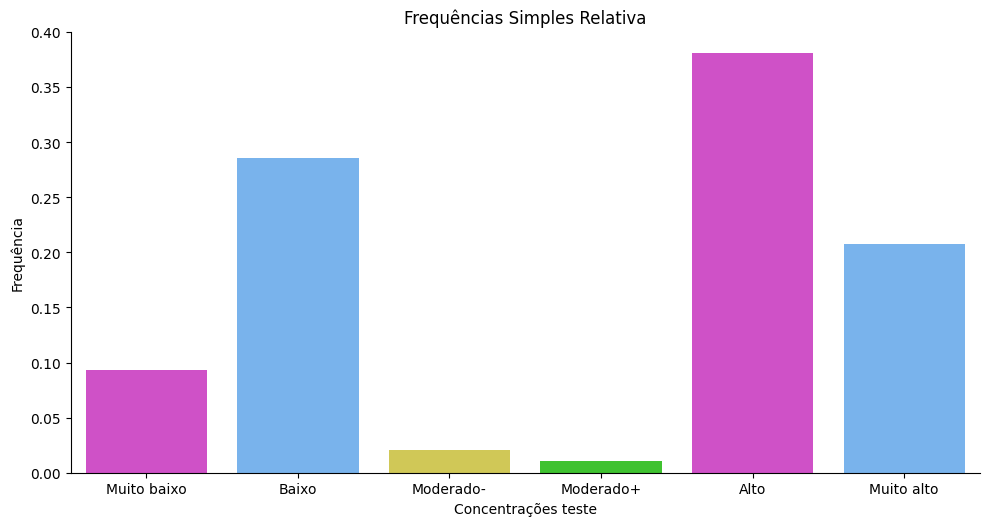

In [52]:
##Para genes

import matplotlib.pyplot as plt
import seaborn as sns

custom_palette = ["#E43CD9", '#66B3FF', "#E4D943", "#2BDA18"] 

sns.catplot(
    kind='bar',
    x=list(freq_expressao['Frequência Simples Relativa'].index),
    y='Frequência Simples Relativa',
    data=freq_expressao,
    palette=custom_palette,
    aspect=2
)
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência")
plt.title("Frequências Simples Relativa")

plt.show()

In [53]:
freq_expressao2

,Frequência Simples Absoluta,Frequência Simples Relativa,Frequência Acumulada Absoluta,Frequência Acumulada Relativa
grupo_pacientes,,,,
Muito baixo,259,0.259,259,0.259
Baixo,241,0.241,500,0.500
Moderado-,121,0.121,621,0.621
Moderado+,142,0.142,763,0.763
Alto,113,0.113,876,0.876
Muito alto,124,0.124,1000,1.000


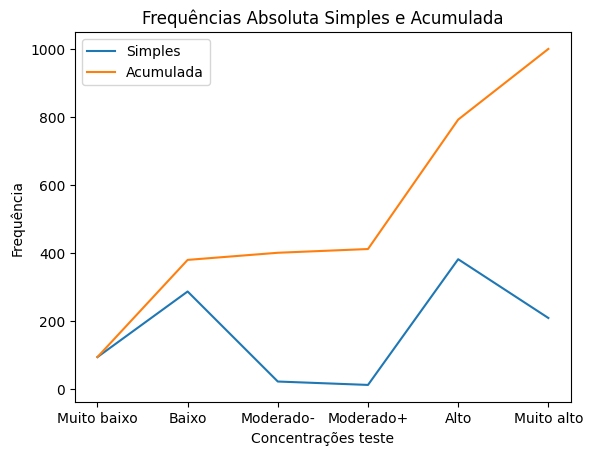

In [54]:
freq_expressao[[freq_expressao.columns[0],freq_expressao.columns[2]]].plot()
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência")
plt.title("Frequências Absoluta Simples e Acumulada")
plt.legend(['Simples', 'Acumulada'])
plt.show()

### Número

C:\Users\julia\AppData\Local\Temp\ipykernel_21484\3336604460.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(
C:\Users\julia\AppData\Local\Temp\ipykernel_21484\3336604460.py:5: UserWarning: 
The palette list has fewer values (4) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.catplot(


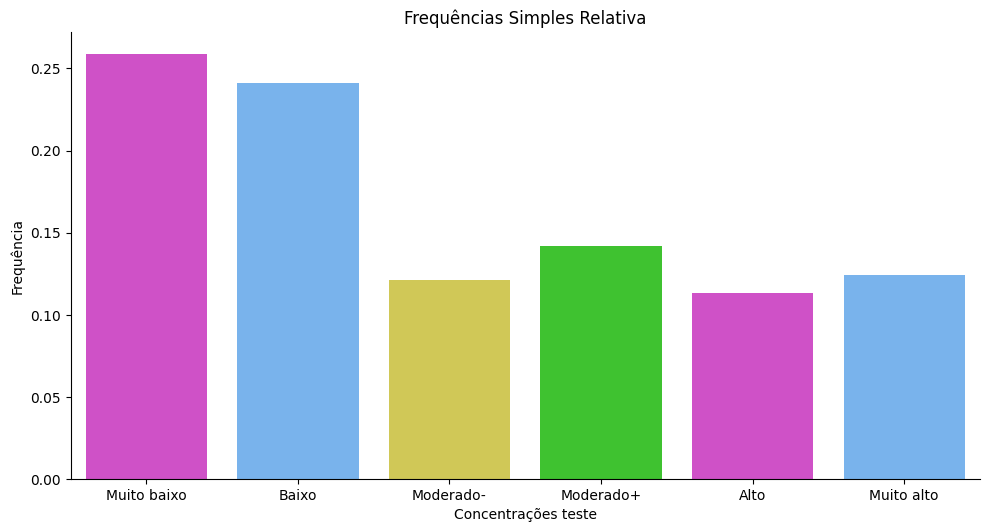

In [55]:
##Pacientes

custom_palette = ["#E43CD9", '#66B3FF', "#E4D943", "#2BDA18"] 

sns.catplot(
    kind='bar',
    x=list(freq_expressao2['Frequência Simples Relativa'].index),
    y='Frequência Simples Relativa',
    data=freq_expressao2,
    palette=custom_palette,
    aspect=2
)
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência")
plt.title("Frequências Simples Relativa")

plt.show()

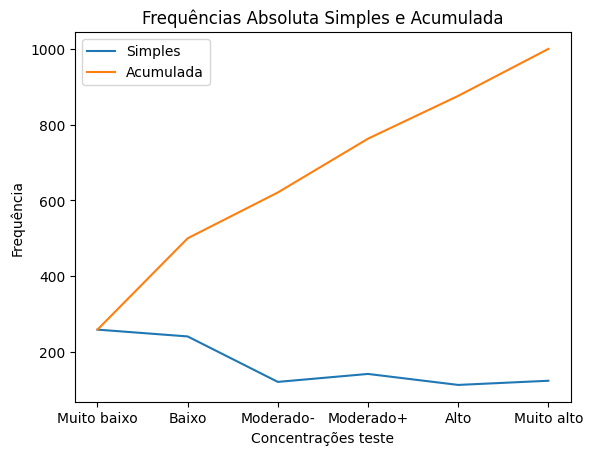

In [56]:

freq_expressao2[[freq_expressao2.columns[0],freq_expressao2.columns[2]]].plot()
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência")
plt.title("Frequências Absoluta Simples e Acumulada")
plt.legend(['Simples', 'Acumulada'])
plt.show()

## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

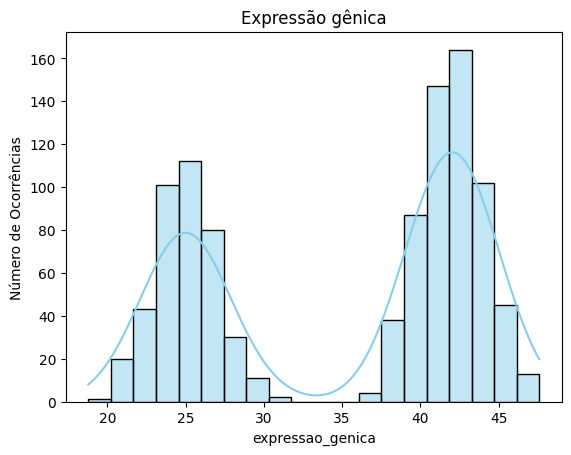

In [57]:
cont = "expressao_genica"
sns.histplot(
    x=cont,
    kde=True,
    bins=20,
    color='skyblue',
    data=df14,
)
plt.title("Expressão gênica")
plt.xlabel(cont)
plt.ylabel("Número de Ocorrências")
plt.show()

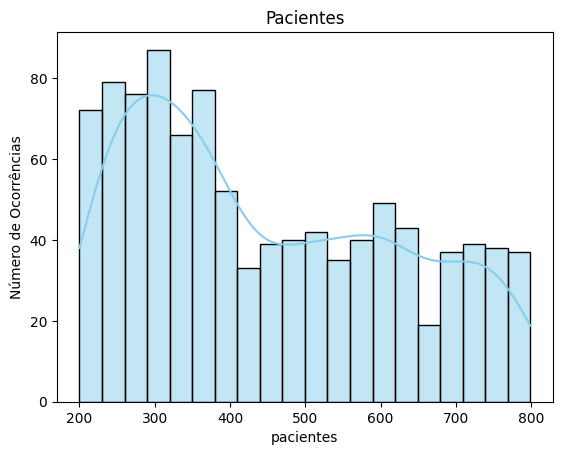

In [58]:
disc = "pacientes"
sns.histplot(
    x=disc,
    kde=True,
    bins=20,
    color='skyblue',
    data=df14,
)
plt.title("Pacientes")
plt.xlabel(disc)
plt.ylabel("Número de Ocorrências")
plt.show()

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

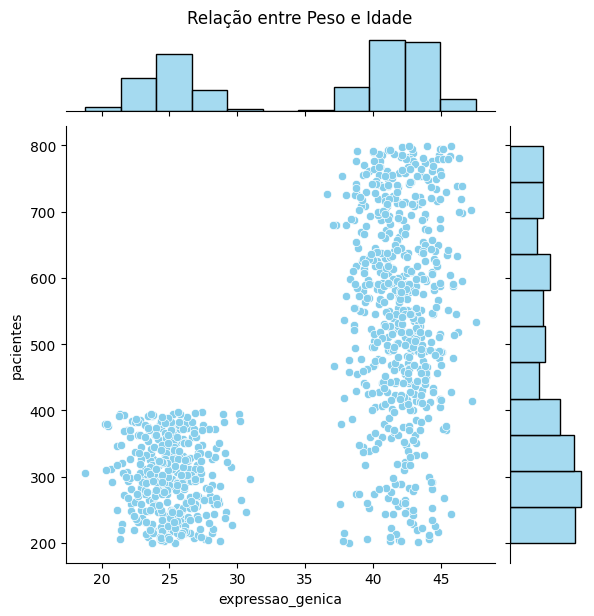

In [59]:
sns.jointplot(
    x=cont,
    y=disc,
    data=df14,
    kind='scatter',
    color='skyblue',
)
plt.suptitle("Relação entre Peso e Idade", y=1.02)
plt.xlabel(cont)
plt.ylabel(disc)
plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

In [60]:
df14

,expressao_genica,pacientes,grupo_expressao,grupo_pacientes
0,43.729644,654,Muito alto,Alto
1,40.271637,626,Alto,Alto
2,41.903770,661,Alto,Alto
3,42.728514,505,Alto,Moderado+
4,44.194451,412,Muito alto,Moderado-
...,...,...,...,...
995,24.248185,257,Baixo,Muito baixo
996,25.841614,303,Baixo,Baixo
997,25.306856,231,Baixo,Muito baixo
998,23.819226,294,Baixo,Muito baixo


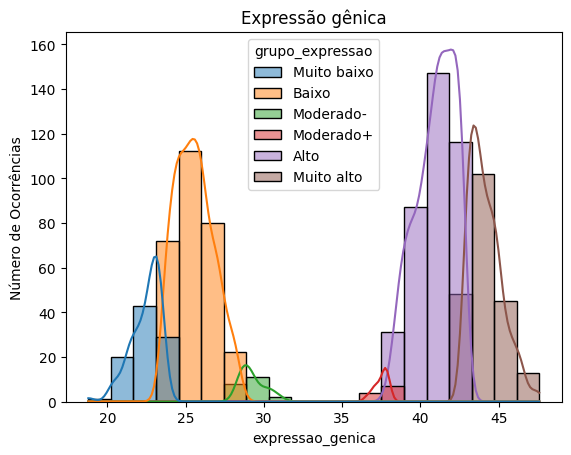

In [61]:
sns.histplot(
    x=cont,
    kde=True,
    bins=20,
    color='skyblue',
    data=df14,
    hue="grupo_expressao"
)
plt.title("Expressão gênica")
plt.xlabel(cont)
plt.ylabel("Número de Ocorrências")
plt.show()

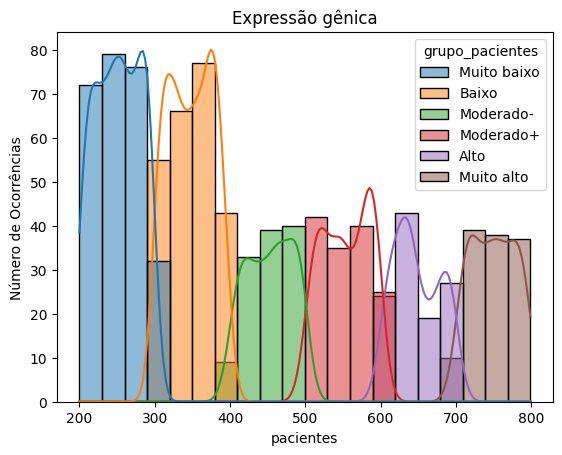

In [62]:
sns.histplot(
    x=disc,
    kde=True,
    bins=20,
    color='skyblue',
    data=df14,
    hue="grupo_pacientes"
)
plt.title("Expressão gênica")
plt.xlabel(disc)
plt.ylabel("Número de Ocorrências")
plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

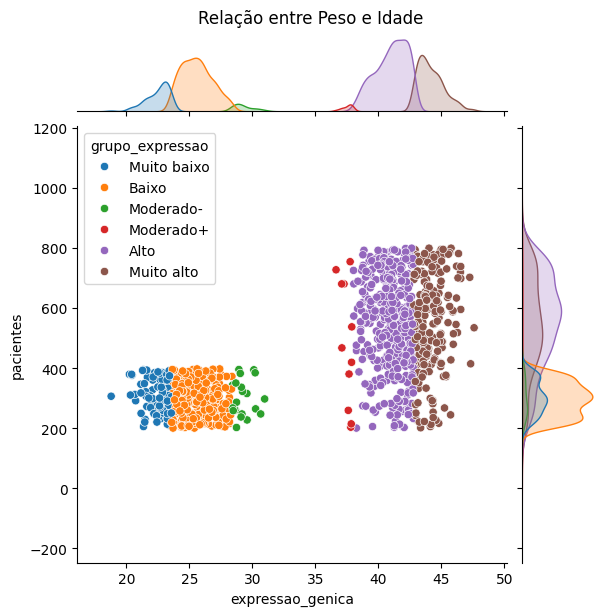

In [63]:
sns.jointplot(
    x=cont,
    y=disc,
    data=df14,
    kind='scatter',
    color='skyblue',
    hue="grupo_expressao"
)
plt.suptitle("Relação entre Peso e Idade", y=1.02)
plt.xlabel(cont)
plt.ylabel(disc)
plt.show()

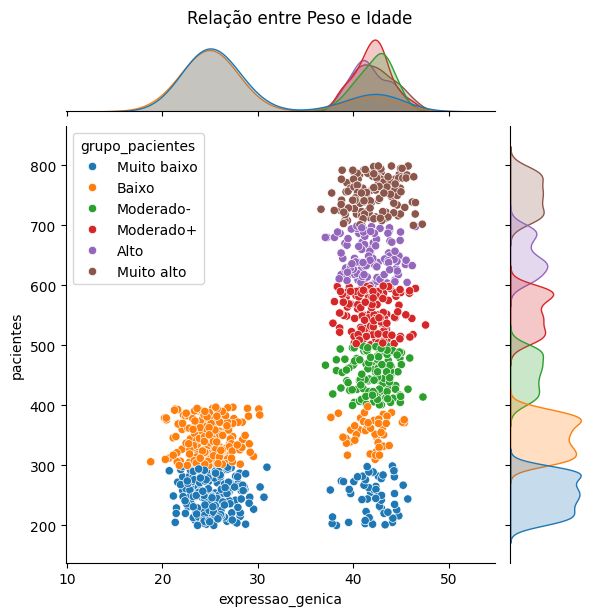

In [64]:
sns.jointplot(
    x=cont,
    y=disc,
    data=df14,
    kind='scatter',
    color='skyblue',
    hue="grupo_pacientes"
)
plt.suptitle("Relação entre Peso e Idade", y=1.02)
plt.xlabel(cont)
plt.ylabel(disc)
plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas|Discreta|
| % de células positivas|Contínua|
| Faixa de pH|Ordinal|
| Valor de pH|Contínua|
| mol/L|Contínua|
| UFC|Discreta|
| D.O.|Contínua|
| Grupo Sanguíneo|Nominal|
| Sorologia|Nominal|